<a href="https://colab.research.google.com/github/Mikomijie/dna-sequence-analyzer/blob/main/oil_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
from google.colab import files
uploaded = files.upload()

Saving Volve production data.xlsx to Volve production data (1).xlsx


In [24]:
import pandas as pd
oil = pd.read_excel("Volve production data.xlsx", sheet_name = "Monthly Production Data" ,skiprows = [1])
oil.head()
oil.columns.tolist()

['Wellbore name',
 'NPDCode',
 'Year',
 'Month',
 'On Stream',
 'Oil',
 'Gas',
 'Water',
 'GI',
 'WI']

In [25]:
print(oil.shape)
print(oil.isnull().sum())
print(oil['Wellbore name'].unique())
print(oil.dtypes)

(526, 10)
Wellbore name      0
NPDCode            0
Year               0
Month              0
On Stream         11
Oil              215
Gas              215
Water            215
GI               526
WI               325
dtype: int64
['15/9-F-1 C' '15/9-F-11' '15/9-F-12' '15/9-F-14' '15/9-F-15 D' '15/9-F-4'
 '15/9-F-5']
Wellbore name     object
NPDCode            int64
Year               int64
Month              int64
On Stream        float64
Oil              float64
Gas              float64
Water            float64
GI               float64
WI               float64
dtype: object


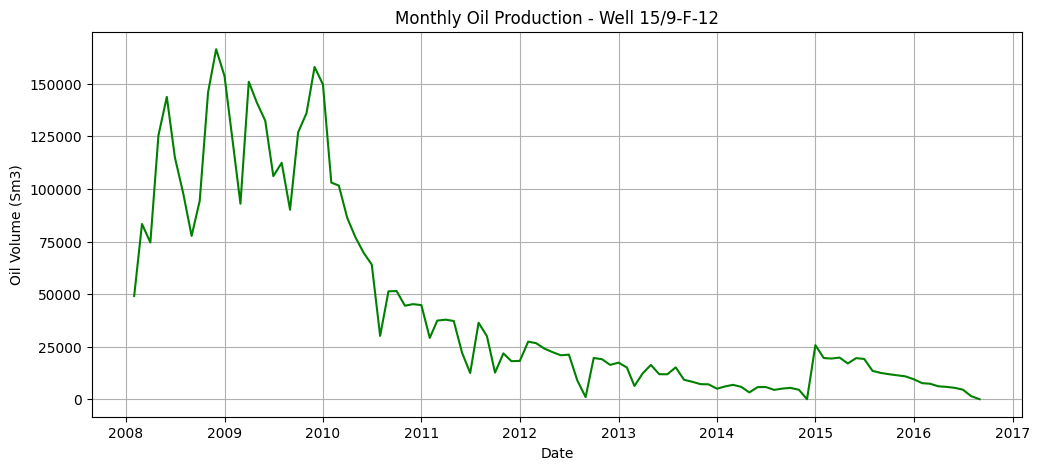

In [26]:
well = oil[oil['Wellbore name']== "15/9-F-12"].copy()
well = well[['Year', 'Month', 'Oil']].dropna()
well = well.sort_values(['Year', 'Month']).reset_index(drop = True)
well['Date'] = pd.to_datetime(well[['Year', 'Month']].assign(Day =1))

import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(well['Date'], well['Oil'], color='green')

plt.xlabel("Date")
plt.title("Monthly Oil Production - Well 15/9-F-12")
plt.ylabel("Oil Volume (Sm3)")
plt.grid(True)
plt.show()

In [27]:
from scipy.optimize import curve_fit
import numpy as np

In [28]:
t = np.arange(len(well) )
q= well['Oil'].values

In [29]:
def arps_decline(t , qi , Di , b):
  return qi/(1 + b * Di * t) ** 1/b

In [30]:
popt,pcov = curve_fit(arps_decline,t,q,p0=[100000, 0.1 , 0.5], maxfev = 10000)
qi_fit, Di_fit,b_fit = popt
print(f"q1 = {qi_fit:.2f}, Di = {Di_fit:.4f} , b= {b_fit:.4f}")

q1 = 61204.52, Di = 0.1271 , b= 0.4247


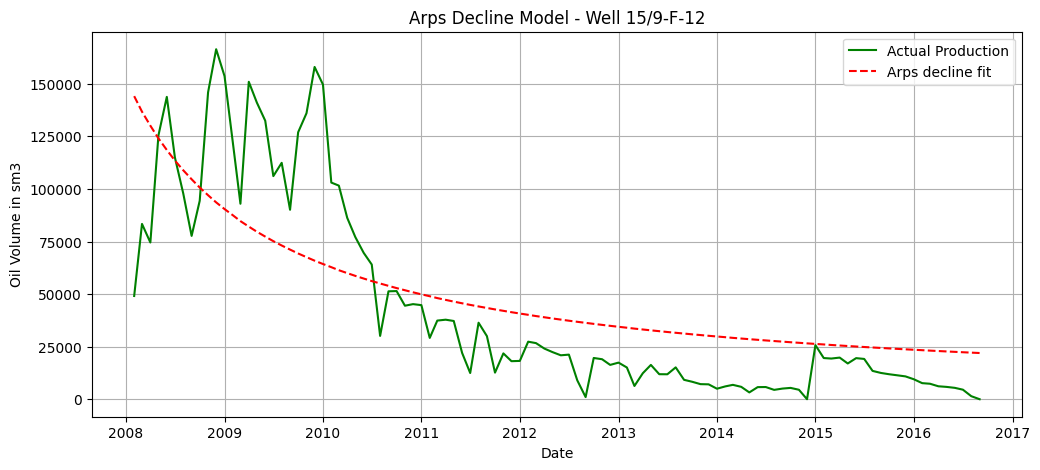

In [31]:
q_pred_arps = arps_decline(t, qi_fit, Di_fit, b_fit)
plt.figure(figsize = (12,5))
import matplotlib.pyplot as plt
plt.plot(well['Date'], q, color = 'green', label = 'Actual Production')
plt.plot(well['Date'], q_pred_arps, color= 'red', linestyle ="--", label = "Arps decline fit")
plt.title("Arps Decline Model - Well 15/9-F-12")
plt.xlabel('Date')
plt.ylabel('Oil Volume in sm3')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
from sklearn.metrics import mean_squared_error
import numpy as np
rmse_arps  = np.sqrt(mean_squared_error(q,q_pred_arps))
print(f"Arps RMSE: {rmse_arps:.2f}")


Arps RMSE: 30628.09


In [33]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
q_scaled = scaler.fit_transform(q.reshape(-1,1))

In [34]:
def create_sequences(data,seq_length):
    X,y = [], []
    for i in range(len(data) - seq_length):
      X.append(data[i:i+seq_length])
      y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 12
X, y_lstm = create_sequences(q_scaled,  seq_length)
print(X.shape, y_lstm.shape)

(92, 12, 1) (92, 1)


In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  LSTM, Dense

model = Sequential()
model.add(LSTM(50, activation = 'relu', input_shape = (seq_length , 1)))
model.add(Dense(1))
model.compile(optimizer = 'adam', loss= 'mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
history = model.fit(X, y_lstm, epochs=100, batch_size=8, verbose=1)
epochs=100
batch_size=8
verbose=1

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0616
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0278
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0183
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0099
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0074
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0064
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0071
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0057
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0085
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0088
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0059
Epoch 12/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0096
Epoch 13/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0077
Epoch 14/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0062
Epoch 15/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss:

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step
LSTM RMSE: 12424.70
Arps RMSE: 30628.09


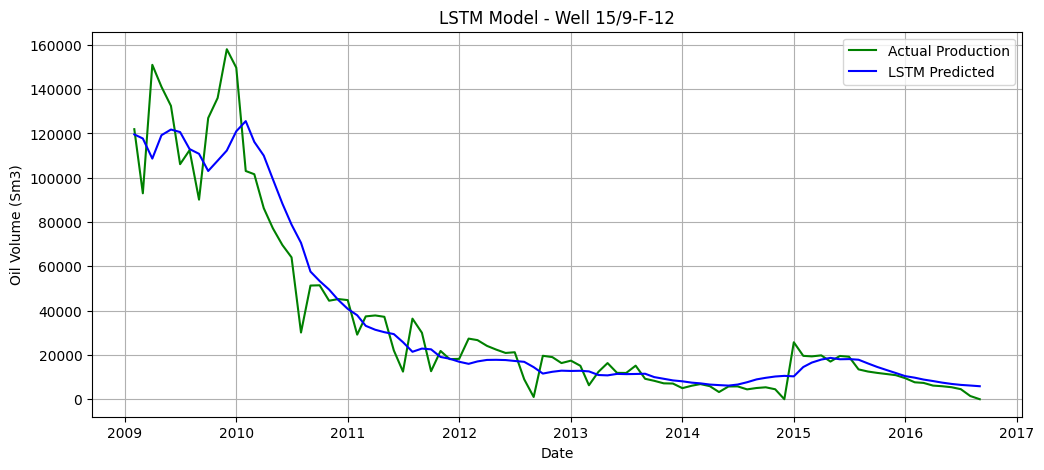

In [43]:
y_pred_scaled = model.predict(X)
y_pred_lstm = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_lstm)

rmse_lstm = np.sqrt(mean_squared_error(y_actual, y_pred_lstm))
print(f"LSTM RMSE: {rmse_lstm:.2f}")
print(f"Arps RMSE: {rmse_arps:.2f}")

plt.figure(figsize=(12,5))
plt.plot(well['Date'][seq_length:], y_actual, color='green', label='Actual Production')
plt.plot(well['Date'][seq_length:], y_pred_lstm, color='blue', label='LSTM Predicted')
plt.title('LSTM Model - Well 15/9-F-12')
plt.xlabel('Date')
plt.ylabel('Oil Volume (Sm3)')
plt.legend()
plt.grid(True)
plt.show()